In [2]:
!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt
! pip install neurokit2
import neurokit2 as nk

print("Let's analyse this data")

Let's analyse this data


In [5]:
record = wfdb.rdrecord('mitdb/100',
                       sampfrom=0,
                       sampto=10000,
                       pn_dir='mitdb')
print(record.sig_name)
print(record.fs)
print(record.p_signal.shape)


['MLII', 'V5']
360
(10000, 2)


In [6]:
ecg_real = record.p_signal[:,0]
print(ecg_real.shape)
print(ecg_real[:5])

(10000,)
[-0.145 -0.145 -0.145 -0.145 -0.145]


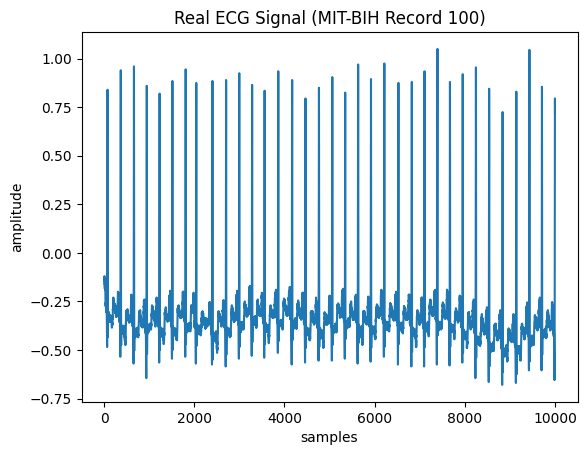

In [7]:


plt.plot(ecg_real)
plt.title("Real ECG Signal (MIT-BIH Record 100)")
plt.xlabel("samples")
plt.ylabel("amplitude")
plt.show()

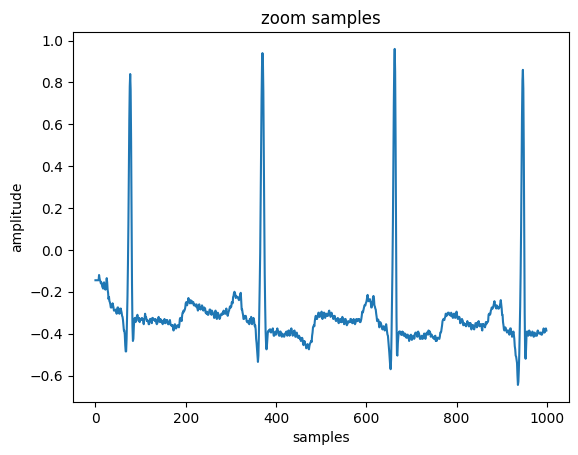

In [8]:
plt.plot(ecg_real[:1000])

plt.title("zoom samples")
plt.xlabel("samples")
plt.ylabel("amplitude")
plt.show()

In [10]:
#R peak detection pipeline

signals_real, info_real= nk.ecg_process(ecg_real, sampling_rate=360)
print(info_real["ECG_R_Peaks"])

[ 370  662  946 1231 1515 1809 2092 2375 2686 2997 3282 3559 3862 4170
 4465 4764 5060 5346 5633 5918 6214 6527 6823 7106 7391 7669 7953 8245
 8539 8837 9141 9431 9710]


In [11]:
#use numpy.diff() to calculate R-R interval

rr_intervals = np.diff(info_real["ECG_R_Peaks"])
print(rr_intervals[:10])

#[slicing is done using index and not time.]

[292 284 285 284 294 283 283 311 311 285]


In [12]:
rr_ms =(rr_intervals/360)*1000
print(rr_ms[:10])

[811.11111111 788.88888889 791.66666667 788.88888889 816.66666667
 786.11111111 786.11111111 863.88888889 863.88888889 791.66666667]


In [15]:
#SDNN and RMSSD on the real data.

sdnn=np.std(rr_ms)
rmssd = np.sqrt(np.mean(np.diff(rr_ms)**2))
print("SDNN", sdnn)
print("RMSSD",rmssd)

SDNN 27.42615998537181
RMSSD 32.351889636350656


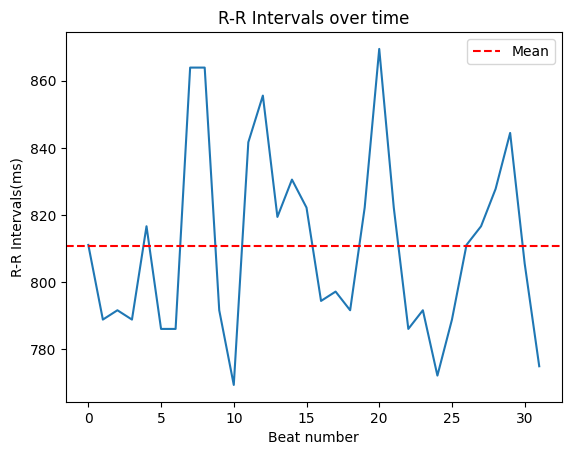

In [17]:
#lets plot this graph

plt.plot(rr_ms)
plt.title("R-R Intervals over time")
plt.xlabel("Beat number")
plt.ylabel("R-R Intervals(ms)")
plt.axhline(y=np.mean(rr_ms), color='r', linestyle='--', label="Mean")
plt.legend()
plt.show()

In [20]:
#LF/HF : frequency domain metrics

from scipy.signal import welch

#welch represents the poer at each frequency in the signal

In [22]:
#at this point  R-R intervals are unevenly spaced in time. for frequency analysis signal needs to be evenly sampled.
# this resampling of R-R intervals into regular time grid is called interpolation.

# create time points for each beat (in seconds)
rr_times = np.cumsum(rr_ms) / 1000

#cumsum = cumulative sum. it adds up all the values progressively.

# create evenly spaced time grid at 4Hz
fs_resample = 4
time_grid = np.arange(rr_times[0], rr_times[-1], 1/fs_resample)

# interpolate R-R intervals onto the even grid
rr_resampled = np.interp(time_grid, rr_times, rr_ms)

print(rr_resampled.shape)

(101,)


In [27]:
#calculate power spectral density using welch method
#just like unpacking, welch returns two things at once

freqs, psd = welch(rr_resampled, fs=fs_resample, nperseg=len(rr_resampled))
print(freqs[:10])
print(psd[:10])

#CHNAGED nperseg = 32 to len(rr_resampled) for better resolution. to get a LF value.



[0.         0.03960396 0.07920792 0.11881188 0.15841584 0.1980198
 0.23762376 0.27722772 0.31683168 0.35643564]
[ 250.50492743 1048.672259    126.4849704   706.35810381 3365.13854143
 4021.93244678   38.08338447 1945.37324787 1817.1181324   274.49847596]


In [28]:
#definfe frequency bands
lf_band = (0.04, 0.15)
hf_band = (0.15, 0.4)

#extract power in each band
lf_power = np.trapz(psd[(freqs>= lf_band[0]) & (freqs <= lf_band[1])],
                  freqs [(freqs>= lf_band[0]) & (freqs <= lf_band[1])])
hf_power = np.trapz (psd[(freqs>= hf_band[0]) & (freqs<= hf_band[1])],
                     freqs[(freqs>=hf_band[0])&(freqs<= hf_band[1])])

print("LF Power:", lf_power)
print("HF Power:", hf_power)
print ("LF/HF Ratio:", lf_power/hf_power)

LF Power: 16.49194206357274
HF Power: 400.89599855462444
LF/HF Ratio: 0.04113770684424932


/tmp/ipykernel_10807/1398671281.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[(freqs>= lf_band[0]) & (freqs <= lf_band[1])],
/tmp/ipykernel_10807/1398671281.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz (psd[(freqs>= hf_band[0]) & (freqs<= hf_band[1])],


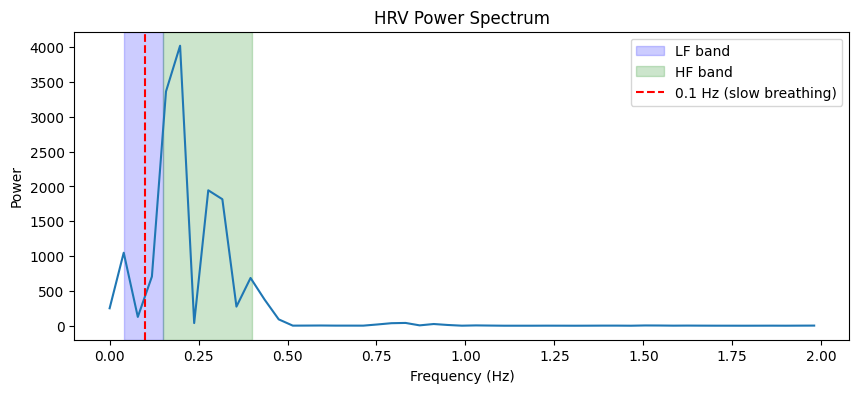

In [29]:
#lets visualise the power spectrum and plot the graph
#axhline = horizontal line
#axvspan = vertical span(draws a shaded vertical region between two x values)

plt.figure(figsize=(10, 4))
plt.plot(freqs, psd)
plt.axvspan(0.04, 0.15, alpha=0.2, color='blue', label='LF band')
plt.axvspan(0.15, 0.4, alpha=0.2, color='green', label='HF band')
plt.axvline(x=0.1, color='red', linestyle='--', label='0.1 Hz (slow breathing)')
plt.title("HRV Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.show()